In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from os.path import join
import os

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id,download_dir
add_to_path(join(root_dir, 'src'))
import utils.preprocessing as preprocessing
import anomaly_detection.deep_learning.AE_GRU as AE
from data_loader import load_data

Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

In [3]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

len(list_session)

40

D'après l'étude faite dans anl02p1-pca on ne garde uniquement les 30 suivantes sessions.

In [4]:
# We only keep normal sessions
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

clean_sessions = [
    k for k in list_session
    if os.path.splitext(os.path.basename(k))[0] not in session_anomaly
]
df_list = []

for cle in clean_sessions:
    df_temp = data_dict[cle].copy()
    df_temp = preprocessing.clean_dataframe(df_temp)
    session_name = os.path.splitext(os.path.basename(cle))[0]
    if 'session_id' not in df_temp.columns:
        df_temp['session_id'] = session_name
    df_list.append(df_temp)

df_filtered = pd.concat(df_list, ignore_index=True)


print(f"Données chargées. Dimensions : {df_filtered.shape}")
print(f"Nombre de sessions saines : {df_filtered['session_id'].nunique()}")
display(df_filtered.head())


Données chargées. Dimensions : (289405, 18)
Nombre de sessions saines : 30


,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-03 22:49:36.502,1916.29,2035.22,2010.47,1983.84,4250.50,4300.35,7630.84,8613.12,4.17052,2.57613,0.985107,-0.180691,-0.472259,248.967,-2.387850,0.00,T24S12-04_E-AL2870
1,2024-05-03 22:49:36.512,1916.29,2036.40,2017.03,1987.99,4000.12,4255.14,7768.87,9137.16,4.42023,2.31616,0.952778,-0.275728,-0.823481,249.055,0.157031,0.01,T24S12-04_E-AL2870
2,2024-05-03 22:49:36.522,1919.14,2041.12,2013.75,1993.19,4080.10,3708.03,8209.24,9542.19,3.98324,2.46781,0.880037,-0.156931,-0.608216,249.232,-1.916580,0.02,T24S12-04_E-AL2870
3,2024-05-03 22:49:36.532,1920.09,2036.40,2013.75,1986.96,3585.15,3214.24,8666.04,9658.90,4.07688,2.51114,0.742637,-0.014376,-1.118060,249.321,-1.508140,0.03,T24S12-04_E-AL2870
4,2024-05-03 22:49:36.542,1920.09,2041.12,2020.31,1991.11,3347.52,3361.45,8725.20,9462.10,4.23295,2.26200,0.758802,-0.145052,-0.959439,249.498,-3.204730,0.04,T24S12-04_E-AL2870


Séparation en un jeu d'entrainement et un jeu de test 

In [5]:

# Liste des noms des sessions 
all_sessions = df_filtered['session_id'].unique()

# Sélection aléatoire de 6 sessions (20% de 30)
random.seed(40)
test_sessions = random.sample(list(all_sessions), 6)
train_sessions = [s for s in all_sessions if s not in test_sessions]

print(f"Sessions d'entraînement : {train_sessions}")
print(f"Sessions de test : {test_sessions}")

df_train = df_filtered[df_filtered['session_id'].isin(train_sessions)].copy()
df_test = df_filtered[df_filtered['session_id'].isin(test_sessions)].copy()


Sessions d'entraînement : ['T24S12-04_E-AL2870', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3070', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3339', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690']
Sessions de test : ['T24S12-04_E-AL3319', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3143']


In [6]:

#on sélectionne uniquement les colonnes que l'on va utiliser
features = [c for c in df_filtered.columns if c not in ['session_id', 'time_real', 'datetime']]

#normalisation avec la moyenne et la variance des données d'entraînement
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [7]:
#With overlapping of sequences (step of 1)
def create_sequences(df_input, features_list, time_steps):
    sequences_list = []
    for _, df_session in df_input.groupby('session_id'):
        values = df_session[features_list].values
        for i in range(len(values) - time_steps + 1):
            seq=values[i : (i + time_steps),:]
            sequences_list.append(seq)
    return np.array(sequences_list)

# Without overlapping
def create_sequences_no_overlap(df_input, features_list, time_steps):
    sequences_list = []
    for _, df_session in df_input.groupby('session_id'):
        values = df_session[features_list].values
        for i in range(0, len(values) - time_steps + 1, time_steps):
            seq = values[i : (i + time_steps), :]
            sequences_list.append(seq)
            
    return np.array(sequences_list)


In [8]:
# CRÉATION DES FENÊTRES PAR SESSION (Pour éviter les chevauchements)
TIME_STEPS = 10 

# On fusionne tout en un seul gros bloc 3D
x_train = create_sequences_no_overlap(df_train, features, TIME_STEPS) #pour l'entrainement pas besoin de faire de chevauchement
x_test = create_sequences(df_test, features, TIME_STEPS)# pour le test c'est nécessaire pour ne pas louper des anomalies au cas où

print(f"Shape x_train : {x_train.shape}")
print(f"Shape x_test : {x_test.shape}")

Shape x_train : (23203, 10, 15)
Shape x_test : (57304, 10, 15)


Le paramètre TIME_STEPS a été fixé à 100 (soit 1 secondes pour 100 Hz) afin de fournir au modèle une fenêtre temporelle correspondant à la durée typique d'un événement dynamique du véhicule (freinage, braquage), lui permettant de comprendre le contexte physique sans saturer sa mémoire à court terme. => Source ?

In [9]:
model = AE.build_cnn_gru_ae(time_steps=x_train.shape[1], nb_features=x_train.shape[2])

# On affiche le résumé de l'architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 10, 128)        │        52,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 10, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 10, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 10, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 10, 32)         │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 10, 16)         │         1,552 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 10, 32)         │         1,568 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 10, 15)         │         1,455 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,823 (1.80 MB)

 Trainable params: 472,823 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Sécurité : Si l'erreur (loss) ne descend plus pendant 3 tours (patience=3), on arrête !
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Début entrainement")

# 2. Lancement de l'apprentissage
history = model.fit(
    x=x_train, 
    y=x_train,            
    epochs=50,            # Nombre maximum de passages sur toutes tes données
    batch_size=256,       # On lui donne les fenêtres par paquets de 256 (soulage la RAM)
    validation_split=0.3, # On garde 30% des données de côté pour évaluer l'IA à chaque tour d'après l'article
    callbacks=[early_stop]
)

print("Entraînement terminé ")

Début entrainement
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - loss: 0.5176 - val_loss: 0.2188
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.1578 - val_loss: 0.1373
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.1178 - val_loss: 0.1204
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.1051 - val_loss: 0.1104
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0974 - val_loss: 0.1041
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0927 - val_loss: 0.1002
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0873 - val_loss: 0.0953
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0830 - val_loss: 0.0905
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0790 - val_loss: 0.0890
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0753 - val_loss: 0.0809
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0696 - val_loss: 0.0768
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5

Calcul des seuils dynamiques selon la méthode de Wang et al. (2025)
726/726 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step

Seuils calculés pour chaque capteur (Beta = 3) :
 - nwl1 : Seuil = 0.1136 (Mu: 0.0376, Sigma: 0.0253)
 - nwl2 : Seuil = 0.1131 (Mu: 0.0389, Sigma: 0.0248)
 - nwl3 : Seuil = 0.1206 (Mu: 0.0407, Sigma: 0.0266)
 - nwl4 : Seuil = 0.1233 (Mu: 0.0420, Sigma: 0.0271)
 - fprd1 : Seuil = 0.4498 (Mu: 0.1600, Sigma: 0.0966)
 - fprd2 : Seuil = 0.4175 (Mu: 0.1556, Sigma: 0.0873)
 - fprd3 : Seuil = 0.3946 (Mu: 0.1383, Sigma: 0.0854)
 - fprd4 : Seuil = 0.3670 (Mu: 0.1327, Sigma: 0.0781)
 - pstr1 : Seuil = 0.3534 (Mu: 0.1123, Sigma: 0.0804)
 - pstr3 : Seuil = 0.3174 (Mu: 0.1070, Sigma: 0.0701)
 - astrw : Seuil = 0.3032 (Mu: 0.0809, Sigma: 0.0741)
 - g2 : Seuil = 0.2248 (Mu: 0.0803, Sigma: 0.0482)
 - ny : Seuil = 0.3609 (Mu: 0.0974, Sigma: 0.0878)
 - vcrf : Seuil = 0.1212 (Mu: 0.0420, Sigma: 0.0264)
 - v2 : Seuil = 0.8354 (Mu: 0.3365, Sigma: 0.1663)


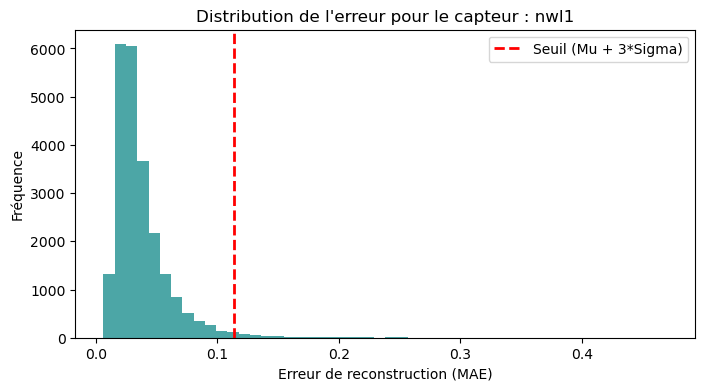

In [12]:
import numpy as np
import matplotlib.pyplot as plt

print("Calcul des seuils dynamiques selon la méthode de Wang et al. (2025)")

# 1. Prédiction sur les données d'entraînement (saines)
x_train_pred = model.predict(x_train)

# 2. Erreur MAE par capteur (On fait la moyenne sur le temps, mais on garde les 15 capteurs)
# axis=1 correspond à la dimension du temps (time_steps).
# Le résultat aura pour dimension (Nombre_de_sequences, 15)
erreurs_par_capteur = np.mean(np.abs(x_train_pred - x_train), axis=1)

# 3. Calcul de la moyenne (mu) et de l'écart-type (sigma) pour CHAQUE capteur
mu = np.mean(erreurs_par_capteur, axis=0)
sigma = np.std(erreurs_par_capteur, axis=0)

# 4. Définition du paramètre Beta (ajustable selon l'article)
# Un beta de 3 équivaut à la règle statistique des 99.7% de confiance
BETA = 3 

# 5. Calcul des seuils dynamiques pour les 15 capteurs
seuils_dynamiques = mu + BETA * sigma

# --- AFFICHAGE POUR TON RAPPORT ---
print(f"\nSeuils calculés pour chaque capteur (Beta = {BETA}) :")
for i, col in enumerate(features[:15]): # Assure-toi que "features" contient bien le nom de tes colonnes
    print(f" - {col} : Seuil = {seuils_dynamiques[i]:.4f} (Mu: {mu[i]:.4f}, Sigma: {sigma[i]:.4f})")

# Visualisation optionnelle : On affiche la distribution du premier capteur pour vérifier
capteur_idx = 0
plt.figure(figsize=(8, 4))
plt.hist(erreurs_par_capteur[:, capteur_idx], bins=50, color='teal', alpha=0.7)
plt.axvline(seuils_dynamiques[capteur_idx], color='red', linestyle='dashed', linewidth=2, label=f'Seuil (Mu + {BETA}*Sigma)')
plt.title(f"Distribution de l'erreur pour le capteur : {features[capteur_idx]}")
plt.xlabel("Erreur de reconstruction (MAE)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()